In [1]:
import numpy as np
import matplotlib.pyplot as plt

from utils import *

np.random.seed(42)

In [2]:
SetStyle()

# Let's check the overlap in events between the OmniLearned score and the X(bb) score

In [3]:
size = "l"
pred_type = "NP"
observable = "mass"
sort_type = "pt"
data_folder = "/pscratch/sd/v/vmikuni/Omnilearned/"

eff = 0.002
get_eff_cut = True
bin = np.linspace(60, 240, 18)

In [19]:
data = EventData.from_npz_folder(
    name="data",
    pred_type=pred_type,
    sort_type="pt",
    region_type="SR1",
    folder=data_folder,
    pattern=f"outputs_pretrain_{size}_jetht_dijet.npz",
    observable=observable,
)

In [45]:
cut_omni = np.quantile(np.min(data.prediction[data.base_mask], 1), 1.0 - eff)
cut_htag = np.quantile(np.min(data.htag[data.base_mask], 1), 1.0 - eff)
ad_mask = data.base_mask & (np.max(data.tau21, axis=1) < 0.45) & (data.mass[:, 1] > 100)

mask_omni = abcd_pred(
    data.prediction[:, 0],
    data.prediction[:, 1],
    cut_omni,
    cut_omni,
    ad_mask & (np.max(data.btag, axis=1) > 0.5847),
)[0]
mask_htag = abcd_pred(data.htag[:, 0], data.htag[:, 1], cut_htag, cut_htag, ad_mask)[0]

print(f"OmniLearned cut threshold for eff {eff} is: {cut_omni}")
print(f"X(bb) cut threshold for eff {eff} is: {cut_htag}")

1.0
OmniLearned cut threshold for eff 0.002 is: 0.9017606973648071
X(bb) cut threshold for eff 0.002 is: 0.8503217101097107


In [46]:
n_total, bin_edges = np.histogram(data.mass[:, 0][mask_omni], bins=bin)
n_triggered, _ = np.histogram(data.mass[:, 0][mask_omni & mask_htag], bins=bin)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
print(n_total)

[ 5  8 27 35 30 25 26 32 46 30 26 23 31 39 33 23  5]


In [47]:
# Calculate efficiency
with np.errstate(divide="ignore", invalid="ignore"):
    efficiency = n_triggered / n_total
    # Binomial uncertainty: sqrt(eff * (1 - eff) / N)
    efficiency_err = np.sqrt(efficiency * (1 - efficiency) / n_total)

# Handle bins with no events
efficiency = np.where(n_total > 0, efficiency, np.nan)
efficiency_err = np.where(n_total > 0, efficiency_err, np.nan)

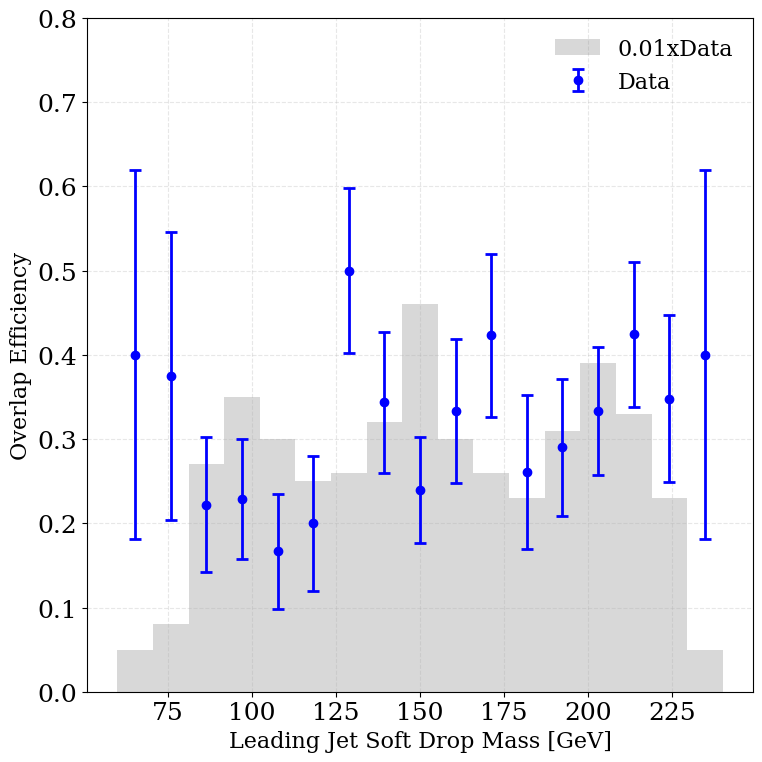

In [51]:
ylabel = "Overlap Efficiency"
xlabel = "Leading Jet Soft Drop Mass [GeV]"
label = "Data"
color = "blue"
marker = "o"
factor = 1e-2


fig, ax = plt.subplots(figsize=(8, 8))

ax.errorbar(
    bin_centers,
    efficiency,
    yerr=efficiency_err,
    fmt=marker,
    color=color,
    label=label,
    capsize=4,
    capthick=2,
    markersize=6,
    linewidth=2,
)
ax.hist(
    data.mass[mask_omni][:, 0],
    bins=bin,
    alpha=0.3,
    label="0.01xData",
    color="gray",
    weights=factor * np.ones_like(data.mass[mask_omni][:, 0]),
)[0]
ax.set_xlabel(xlabel, fontsize=16)
ax.set_ylabel(ylabel, fontsize=16)
ax.set_ylim(0.0, 0.8)
ax.grid(True, alpha=0.3, linestyle="--")

if label is not None:
    ax.legend(loc="best", fontsize=16)


plt.tight_layout()
plt.savefig("plots/overlap.pdf")